In [9]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# 파일 읽기 (인코딩은 상황에 따라 'cp949', 'utf-8', 'euc-kr' 등 시도)
try:
    df = pd.read_csv(filename, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding='utf-8')
except:
    df = pd.read_csv(filename, encoding='euc-kr')

# 데이터 미리보기
print(f"✅ 데이터 '{filename}' 로드 완료!")

filtered_df = df[df['설치목적구분'].isin(['생활방범', '어린이보호'])]

# 원하는 컬럼만 선택 (예시: 관리기관명, 소재지도로명주소, 설치목적구분, 카메라대수, WGS84위도, WGS84경도)
selected_columns = ['관리기관명', '소재지도로명주소', '설치목적구분', '카메라대수', 'WGS84위도', 'WGS84경도']
result_df = filtered_df[selected_columns]

# 기존 '번호' 컬럼이 있으면 삭제
if '번호' in result_df.columns:
    result_df = result_df.drop(columns=['번호'])

# 번호를 1부터 시작해서 오름차순으로 부여
result_df.insert(0, '번호', range(1, len(result_df) + 1))

# 결과 일부 출력
result_df

Saving 인천 CCTV정보 (1).csv to 인천 CCTV정보 (1) (1).csv
✅ 데이터 '인천 CCTV정보 (1) (1).csv' 로드 완료!


,번호,관리기관명,소재지도로명주소,설치목적구분,카메라대수,WGS84위도,WGS84경도
0,1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,1,37.253792,126.466879
1,2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,1,37.254073,126.512068
2,3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,1,37.257637,126.499781
3,4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,3,37.281184,126.485711
4,5,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,1,37.279928,126.454657
...,...,...,...,...,...,...,...
11876,10366,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737960,126.515781
11877,10367,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.737950,126.515244
11878,10368,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737801,126.515021
11879,10369,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.747541,126.474915


In [10]:
# 지도로 CCTV분포 히트맵

import folium
from folium.plugins import HeatMap

# 지도 중심(인천시청 기준)
center_lat, center_lon = 37.456255, 126.705206
m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# 히트맵 데이터: [위도, 경도, 카메라대수]
heat_data = [
    [row['WGS84위도'], row['WGS84경도'], row['카메라대수']]
    for idx, row in result_df.iterrows()
    if not pd.isnull(row['WGS84위도']) and not pd.isnull(row['WGS84경도'])
]

HeatMap(heat_data, radius=8, max_zoom=13).add_to(m)
m


In [11]:
import re

# 함수: 주소에서 군/구 추출
def extract_district(address):
    if pd.isnull(address):
        return None
    # 시/도명 제거
    address_no_city = re.sub(
        r'^(서울특별시|부산광역시|대전광역시|인천광역시|광주광역시|대구광역시|울산광역시|세종특별자치시|경기도|강원도|충청북도|충청남도|전라북도|전라남도|경상북도|경상남도|제주특별자치도)',
        '', address
    )
    # 군/구 추출 (띄어쓰기 없어도 가능)
    match = re.search(r'([가-힣]+(군|구))', address_no_city)
    if match:
        return match.group(1)
    else:
        return None

# '군구' 컬럼이 없으면 새로 생성
if '군구' not in result_df.columns:
    result_df['군구'] = None  # 또는 result_df['군구'] = np.nan

# 군구 결측치 채우기
result_df['군구'] = result_df['군구'].fillna(
    result_df['소재지도로명주소'].apply(extract_district)
)

# 여전히 결측(공란)인 행 제거
result_df = result_df.dropna(subset=['군구'])

# 결과 확인
print(result_df[['소재지도로명주소', '군구']].head())

                     소재지도로명주소   군구
0     인천광역시 옹진군 영흥면 영흥로 440-8  옹진군
1       인천광역시 옹진군 영흥면 선재로 358  옹진군
2   인천광역시 옹진군 영흥면 영흥북로35번길 34  옹진군
3      인천광역시 옹진군 영흥면 영흥북로 389  옹진군
4  인천광역시 옹진군 영흥면 영흥서로496번길 55  옹진군


<ipython-input-11-83fc0672d5b8>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['군구'] = None  # 또는 result_df['군구'] = np.nan
<ipython-input-11-83fc0672d5b8>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['군구'] = result_df['군구'].fillna(


In [12]:
result_df

,번호,관리기관명,소재지도로명주소,설치목적구분,카메라대수,WGS84위도,WGS84경도,군구
0,1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,1,37.253792,126.466879,옹진군
1,2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,1,37.254073,126.512068,옹진군
2,3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,1,37.257637,126.499781,옹진군
3,4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,3,37.281184,126.485711,옹진군
4,5,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...
11876,10366,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737960,126.515781,강화군
11877,10367,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.737950,126.515244,강화군
11878,10368,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737801,126.515021,강화군
11879,10369,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.747541,126.474915,강화군


In [ ]:
# '미추홀구구' 행 제거
filtered_df = result_df[~result_df['군구'].isin(['미추홀구구'])].copy()

# '번호' 오름차순 정렬 및 인덱스 재설정
filtered_df = filtered_df.sort_values(by='번호').reset_index(drop=True)

# 결과 확인
filtered_df

,번호,관리기관명,소재지도로명주소,설치목적구분,카메라대수,WGS84위도,WGS84경도,군구
0,1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,1,37.253792,126.466879,옹진군
1,2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,1,37.254073,126.512068,옹진군
2,3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,1,37.257637,126.499781,옹진군
3,4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,3,37.281184,126.485711,옹진군
4,5,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...,...
9054,10366,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737960,126.515781,강화군
9055,10367,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.737950,126.515244,강화군
9056,10368,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737801,126.515021,강화군
9057,10369,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.747541,126.474915,강화군


In [ ]:
if '번호' in filtered_df.columns:
    filtered_df = filtered_df.drop(columns=['번호'])

# 결과 확인
filtered_df

,관리기관명,소재지도로명주소,설치목적구분,카메라대수,WGS84위도,WGS84경도,군구
0,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥로 440-8,생활방범,1,37.253792,126.466879,옹진군
1,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 선재로 358,생활방범,1,37.254073,126.512068,옹진군
2,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로35번길 34,생활방범,1,37.257637,126.499781,옹진군
3,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥북로 389,생활방범,3,37.281184,126.485711,옹진군
4,인천광역시 옹진군 재난안전담당관,인천광역시 옹진군 영흥면 영흥서로496번길 55,생활방범,1,37.279928,126.454657,옹진군
...,...,...,...,...,...,...,...
9054,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737960,126.515781,강화군
9055,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.737950,126.515244,강화군
9056,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,2,37.737801,126.515021,강화군
9057,인천광역시 강화군,인천광역시 강화군 강화읍,생활방범,3,37.747541,126.474915,강화군


In [ ]:
# 군구별 항목 개수 계산
count_by_district1 = filtered_df['군구'].value_counts().sort_index()

# 결과 출력
print(count_by_district1)

군구
강화군      789
계양구     1039
남동구     1189
동구       332
미추홀구    2449
부평구     1248
서구       758
연수구      471
옹진군      121
중구       663
Name: count, dtype: int64


In [5]:
!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Nanum 글꼴 설치
!apt-get -y install fonts-nanum

# matplotlib에서 한글 폰트 사용 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 나눔 글꼴 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')

import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 글꼴 경로 추가
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 한글을 사용할 수 있도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 34 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0

Index(['FULL_NM', 'SGG_CD', 'SGG_NM', 'SHAPE_AREA', 'SHAPE_LEN', 'SGG_CD_L',
       'Fisheries', 'Employment', 'Road Act', 'Ship Crew', 'Resident R',
       'Public Off', 'Trucking T', 'Negligent', 'Specialize', 'Mountainou',
       'Air Qualit', 'Immigratio', 'Other Obsc', 'Negligen_1', 'Special Ac',
       'Fisherie_1', 'Road Traff', 'Punishment', 'Medical Se', 'Perjury an',
       'Trademark', 'Occupation', 'Act on the', 'Building A', 'Child Welf',
       'Act on t_1', 'Extortion', 'Act on t_2', 'Narcotics', 'Breach of',
       'False Accu', 'Gambling a', 'Occupati_1', 'Minor Offe', 'Food Sanit',
       'Military S', 'Act on t_3', 'Reserve Fo', 'Electronic', 'Juvenile P',
       'Copyright', 'Obstructio', 'Obstruct_1', 'Housebreak', 'Road Tra_1',
       'Workers' R', 'Document', 'Act on Pro', 'Road Tra_2', 'Threats',
       'Motor Vehi', 'Credit Bus', 'Road Tra_3', 'Motor Ve_1', 'Honor',
       'Sexual Vio', 'Bodily Inj', 'Labor Stan', 'Other Spec', 'Damage (or',
       'Embezzleme'

<Axes: >

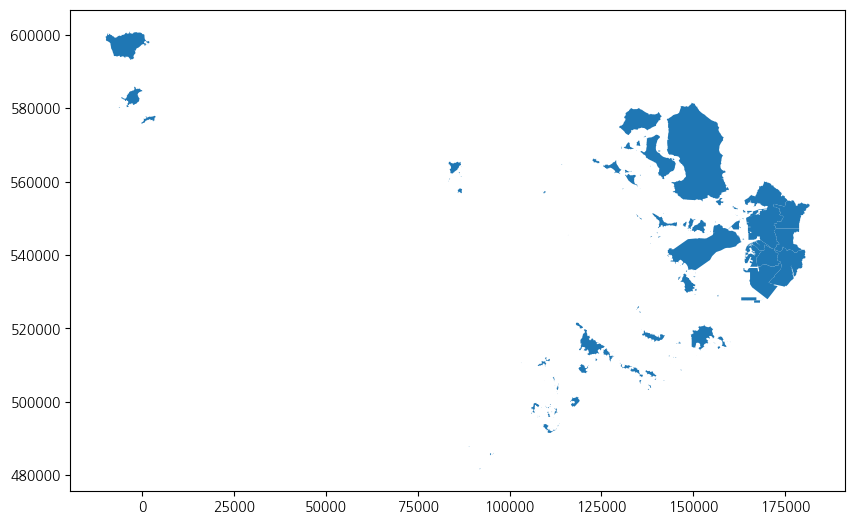

In [ ]:
import geopandas as gpd

# .shp 파일 경로 지정
shp_path = '/content/drive/Criminal+area/Criminal area.shp'  # Colab/로컬 경로에 맞게 수정

# GeoDataFrame으로 불러오기
gdf = gpd.read_file(shp_path)

# 인천의 군/구 이름 리스트 (예시, 실제 데이터의 컬럼명과 값에 맞게 수정)
incheon_districts = [
    '인천광역시 중구', '인천광역시 동구', '인천광역시 미추홀구', '인천광역시 연수구', '인천광역시 남동구', '인천광역시 부평구', '인천광역시 계양구', '인천광역시 서구', '인천광역시 강화군', '인천광역시 옹진군'
]

# 군/구명이 들어있는 컬럼명 확인 (예: 'SIG_KOR_NM', '군구', 'adm_nm' 등)
print(gdf.columns)

# 예시: 컬럼명이 'SIG_KOR_NM'인 경우
incheon_gdf = gdf[gdf['FULL_NM'].isin(incheon_districts)]

# 결과 확인
print(incheon_gdf[['FULL_NM']].head())

# 지도 시각화
incheon_gdf.plot(figsize=(10, 10))

Index(['FULL_NM', 'SGG_CD', 'SGG_NM', 'SHAPE_AREA', 'SHAPE_LEN', 'SGG_CD_L',
       'Fisheries', 'Employment', 'Road Act', 'Ship Crew', 'Resident R',
       'Public Off', 'Trucking T', 'Negligent', 'Specialize', 'Mountainou',
       'Air Qualit', 'Immigratio', 'Other Obsc', 'Negligen_1', 'Special Ac',
       'Fisherie_1', 'Road Traff', 'Punishment', 'Medical Se', 'Perjury an',
       'Trademark', 'Occupation', 'Act on the', 'Building A', 'Child Welf',
       'Act on t_1', 'Extortion', 'Act on t_2', 'Narcotics', 'Breach of',
       'False Accu', 'Gambling a', 'Occupati_1', 'Minor Offe', 'Food Sanit',
       'Military S', 'Act on t_3', 'Reserve Fo', 'Electronic', 'Juvenile P',
       'Copyright', 'Obstructio', 'Obstruct_1', 'Housebreak', 'Road Tra_1',
       'Workers' R', 'Document', 'Act on Pro', 'Road Tra_2', 'Threats',
       'Motor Vehi', 'Credit Bus', 'Road Tra_3', 'Motor Ve_1', 'Honor',
       'Sexual Vio', 'Bodily Inj', 'Labor Stan', 'Other Spec', 'Damage (or',
       'Embezzleme'

<Axes: >

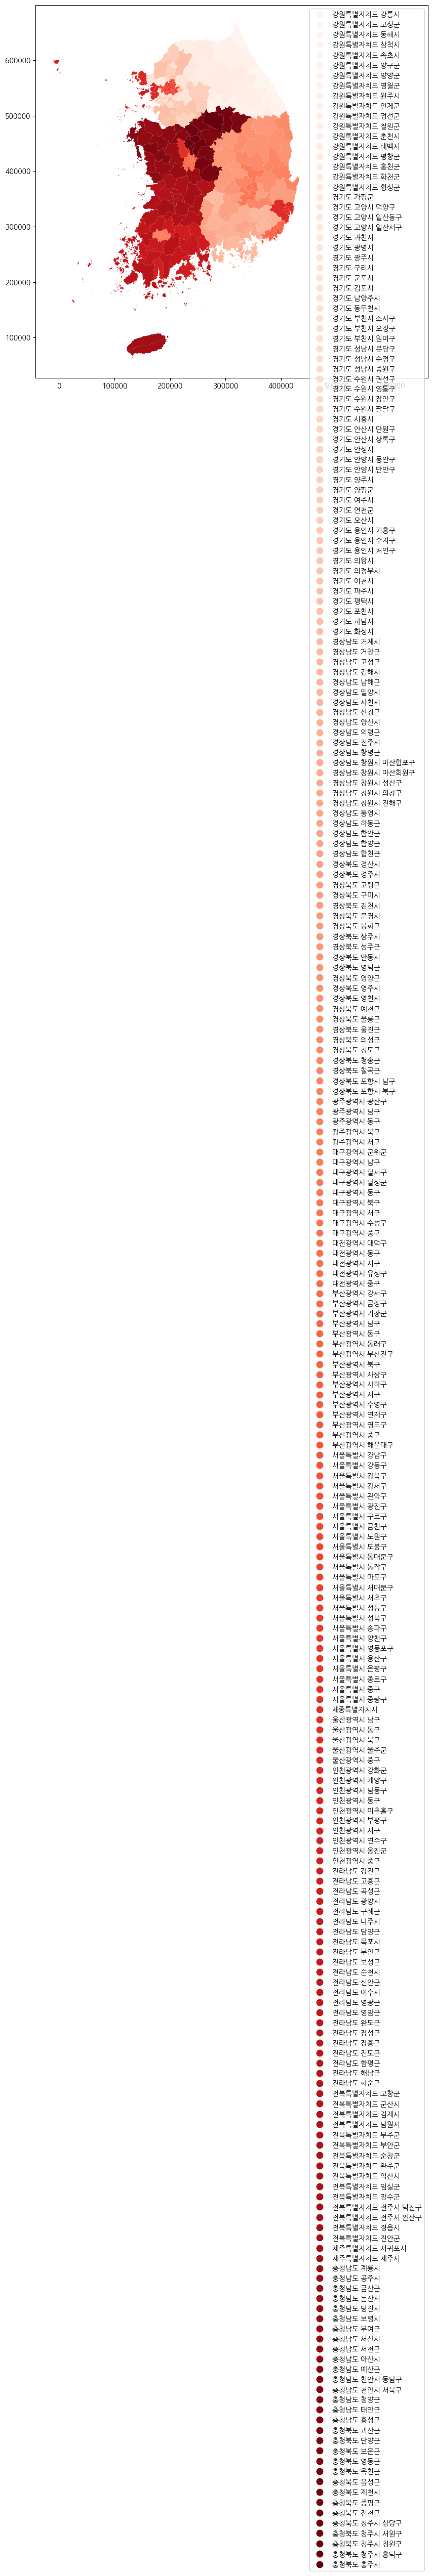

In [ ]:
import geopandas as gpd

# .shp 파일 경로 지정
shp_path = '/content/drive/Criminal+area/Criminal area.shp'  # Colab/로컬 경로에 맞게 수정

# GeoDataFrame으로 불러오기
gdf = gpd.read_file(shp_path)

# 데이터 확인
print(gdf.columns)
print(gdf.head())

# 예: 시군구별 전체 범죄 건수 Choropleth 시각화
gdf.plot(column='FULL_NM', cmap='Reds', legend=True, figsize=(10,10))

In [1]:
from google.colab import files
uploaded = files.upload()

Saving 인천 CCTV정보 (1).csv to 인천 CCTV정보 (1).csv
